In [58]:
import matplotlib.pyplot as plt
from itertools import product
import json
import os

In [59]:
ckpts = [0, 2321, 4642, 6963]
cfg_scales = [1.0, 1.4, 1.8]
svdd_options = [False, True]

epochs = 3
lr = 2e-4
batch_size = 8
num_unmask_steps = 128
p_uncond = 0.0
num_cands = 4
instruct = True

In [60]:
all_data = {}

In [61]:
for ckpt_num, cfg_scale, svdd in product(ckpts, cfg_scales, svdd_options):

    instruct_str = '-instruct' if instruct else ''
    svdd_str = '-svdd' if svdd else ''
    num_cands_str = f'_{num_cands}numcands' if svdd else ''

    if ckpt_num == 0:
        output_path = f'./results{instruct_str}{svdd_str}/llada_untrained/eval_{num_unmask_steps}un_{cfg_scale}cfgscale{num_cands_str}.json'
    else:
        output_path = f'./results{instruct_str}{svdd_str}/llada_{epochs}ep-{batch_size}bs-{lr}lr-{p_uncond}puncond/eval_{num_unmask_steps}un_{ckpt_num}ch_{cfg_scale}cfgscale{num_cands_str}.json'

    with open(output_path, 'r') as f:
        data = json.load(f)

    all_data[(ckpt_num, cfg_scale, svdd)] = data

baseline_output_path = f'./results{instruct_str}/baseline_eval.json'
with open(baseline_output_path, 'r') as f:
    baseline_data = json.load(f)

In [62]:
os.makedirs('./plots', exist_ok=True)

In [66]:
for metric in all_data[all_data.keys().__iter__().__next__()].keys():
    for svdd in [True, False]:
        fig, ax = plt.subplots(figsize=(8, 6))
        # ax.axhline(y=baseline_data[metric], color='r', linestyle='--', label='Baseline')
        for cfg_scale in cfg_scales:
            metric_values = []
            ckpt_nums = []
            for ckpt_num in ckpts:
                key = (ckpt_num, cfg_scale, svdd)
                if key in all_data:
                    metric_values.append(all_data[key][metric])
                    ckpt_nums.append(ckpt_num)
            label = f'cfg_scale={cfg_scale}'
            ax.plot(ckpt_nums, metric_values, marker='o', label=label)
        fig.suptitle(f'Metric: {metric}', fontsize=20)
        # ax.title(f'Metric: {metric}')
        ax.set_xlabel('Checkpoint Number', fontsize=16)
        ax.set_xticks(ckpts)
        ax.set_xticklabels(ckpts, fontsize=16)
        ax.set_ylabel(metric, fontsize=16)
        ax.tick_params(axis='y', labelsize=16)
        # ax.legend()
        ax.grid()
        fig.tight_layout()
        fig.savefig(f'./plots/{metric}_svdd_{svdd}.png')
        plt.close(fig)

In [67]:
handles, labels = ax.get_legend_handles_labels()
fig = plt.figure(figsize=(8, 6))
fig.legend(handles, labels, loc='center', ncol=len(labels))
fig.tight_layout()
fig.savefig('./plots/legend.png', bbox_inches='tight')
plt.close(fig)

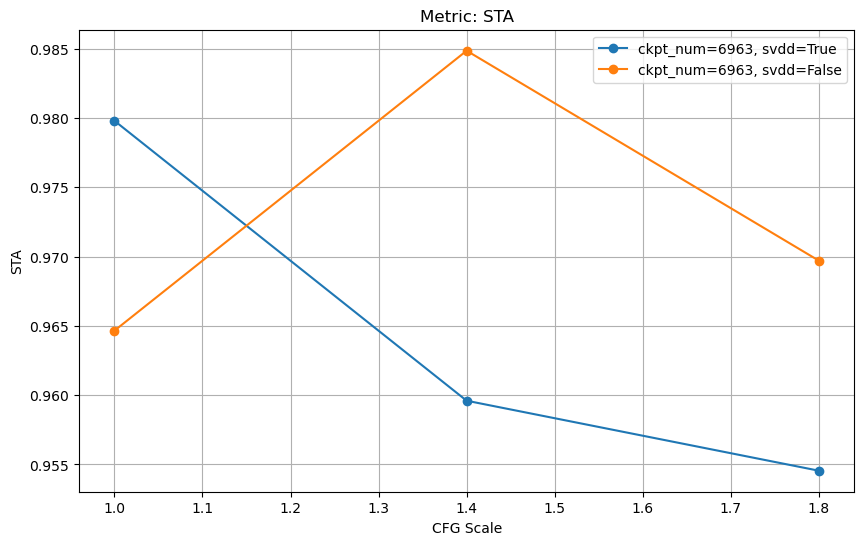

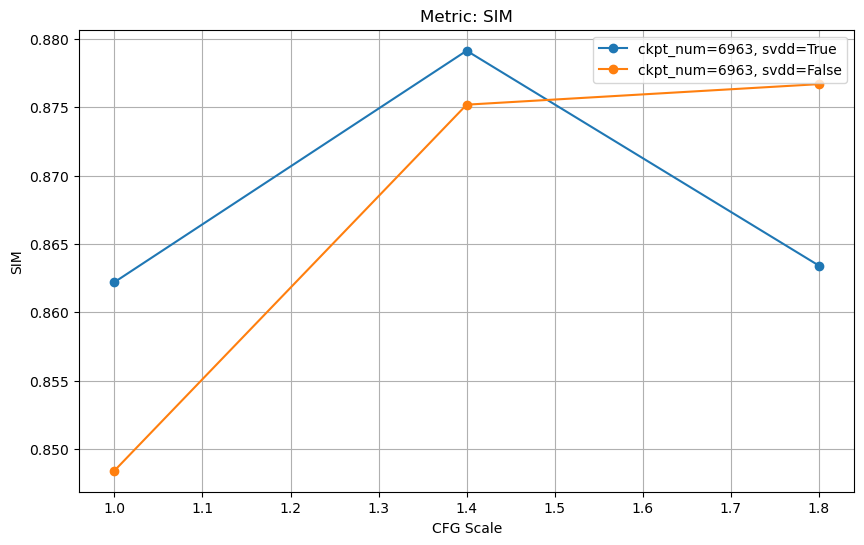

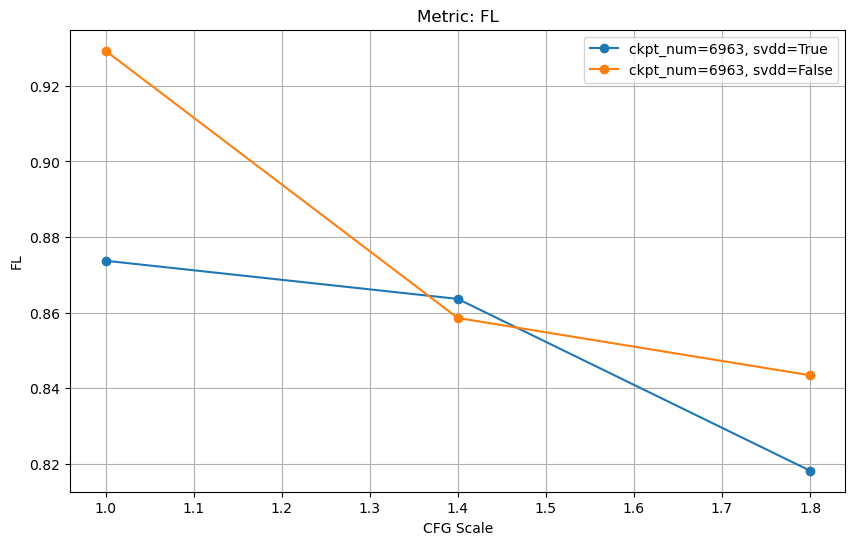

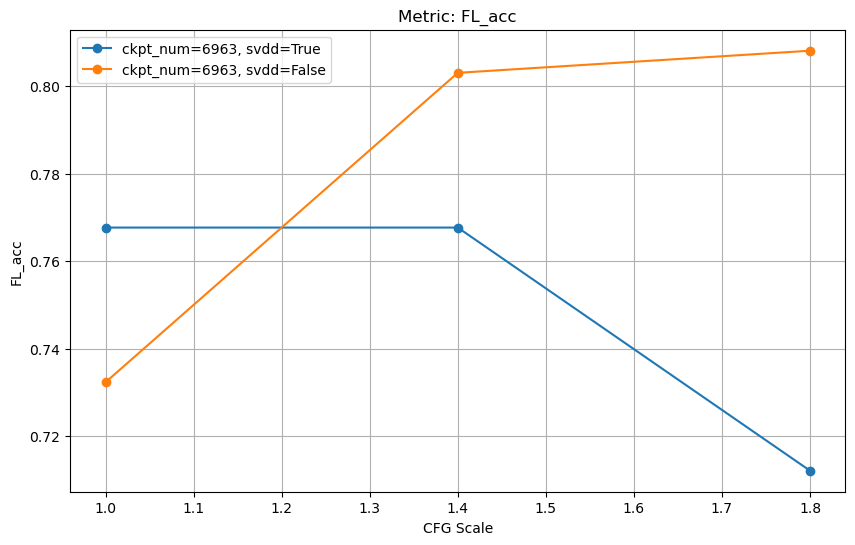

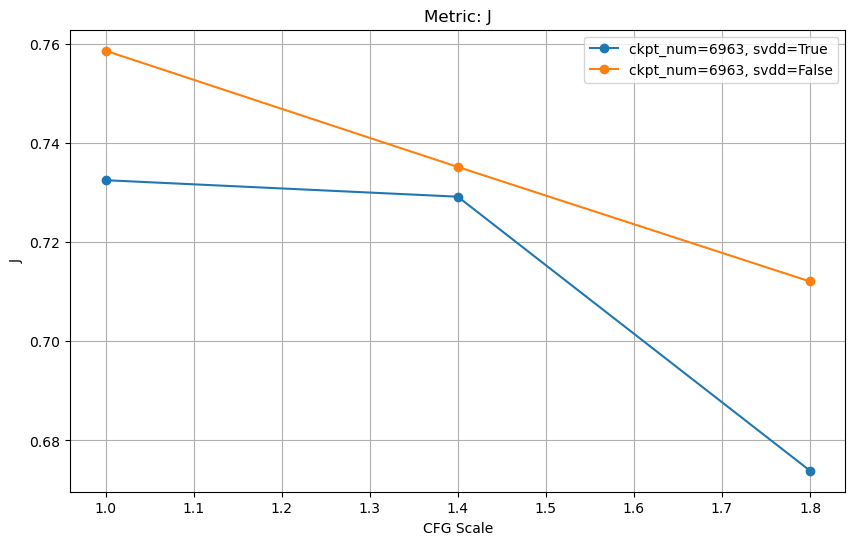

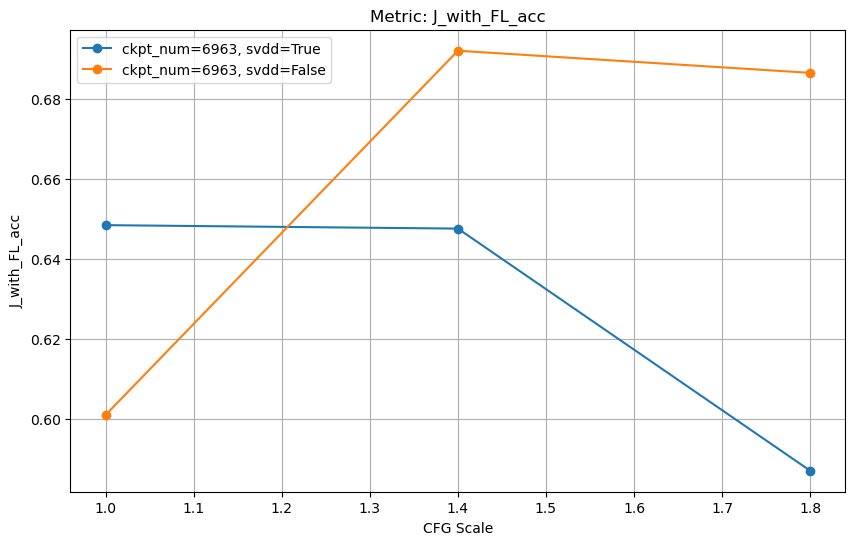

In [ ]:
for metric in all_data[all_data.keys().__iter__().__next__()].keys():
    plt.figure(figsize=(10, 6))
    plt.axhline(y=baseline_data[metric], color='r', linestyle='--', label='Baseline')
    for svdd in [True, False]:
        for ckpt_num in ckpts[-1:]:
            metric_values = []
            cfg_scales_list = []
            for cfg_scale in cfg_scales:
                key = (ckpt_num, cfg_scale, svdd)
                if key in all_data:
                    metric_values.append(all_data[key][metric])
                    cfg_scales_list.append(cfg_scale)
            label = f'ckpt_num={ckpt_num}, svdd={svdd}'
            plt.plot(cfg_scales_list, metric_values, marker='o', label=label)
    plt.title(f'Metric: {metric}')
    plt.xlabel('CFG Scale')
    plt.ylabel(metric)
    plt.legend()
    plt.grid()
    plt.show()